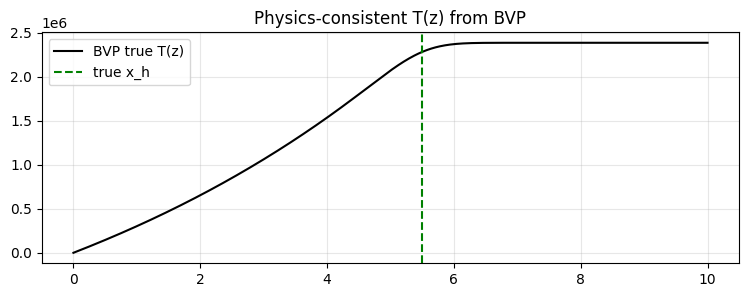

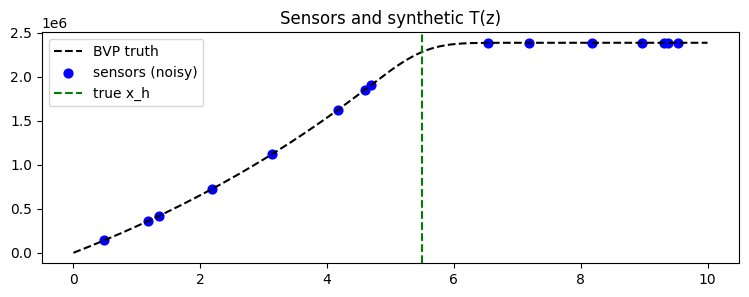

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,513 (33.25 KB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch    1 | Loss 1.118e+09 | data 3.826e+07 pde 1.079e+09 dir 1.111e-03 neu 1.055e+02
Epoch  500 | Loss 9.046e+08 | data 3.805e+07 pde 8.662e+08 dir 2.070e+03 neu 0.000e+00
Epoch 1000 | Loss 9.329e+08 | data 3.794e+07 pde 8.940e+08 dir 5.049e+03 neu 0.000e+00
Epoch 1500 | Loss 8.154e+08 | data 3.783e+07 pde 7.759e+08 dir 8.760e+03 neu 0.000e+00
Epoch 2000 | Loss 7.066e+08 | data 3.773e+07 pde 6.662e+08 dir 1.316e+04 neu 0.000e+00
Epoch 2500 | Loss 7.642e+08 | data 3.762e+07 pde 7.230e+08 dir 1.816e+04 neu 0.000e+00
Epoch 3000 | Loss 7.845e+08 | data 3.751e+07 pde 7.422e+08 dir 2.375e+04 neu 0.000e+00
Epoch 3500 | Loss 7.349e+08 | data 3.740e+07 pde 6.915e+08 dir 2.995e+04 neu 0.000e+00
Training time (s): 22.315815448760986

FINAL RESULTS
True hotspot: 5.5000 m
Predicted hotspot (argmax(T_pred)): 5.7479 m
Error: 4.507 %


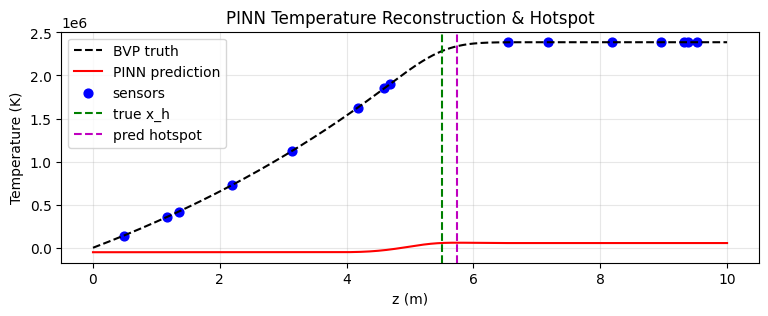

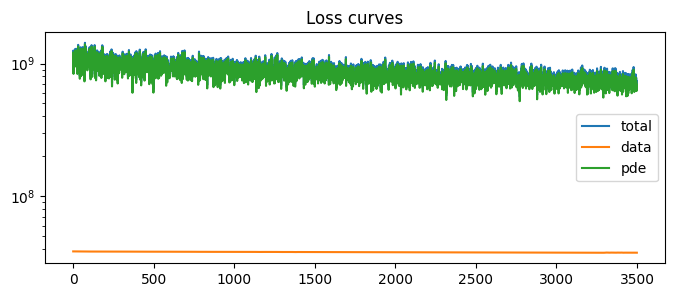

In [16]:
# cleaned_inverse_pinn_no_xh.py
# Clean PINN (NO x_h_var), physics-consistent BVP -> PINN -> hotspot via T argmax
# Paste into one Colab cell. If SciPy missing: run "!pip install scipy" first.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import tensorflow as tf
import time

# reproducibility & dtype
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.backend.set_floatx('float32')

# -----------------------------
# Physical parameters (kept realistic/stable)
# -----------------------------
L = 10.0
u = 0.03
rhoCp = 1.0
k = 0.2

neg_dH = 300.0        # heat-release scaling
A_true = 400.0        # Gaussian amplitude
sigma_true = 0.6      # Gaussian width (m)
true_xh = 5.5         # true hotspot location (used to synthesize data)
T_in = 300.0

# -----------------------------
# Reaction & ODE (first-order system)
# -----------------------------
def rA(z, xh=true_xh, A=A_true, sigma=sigma_true):
    return A * np.exp(-((z - xh)**2) / (sigma**2 + 1e-12))

def ode_system(z, y):
    # y[0] = T, y[1] = T'
    Tz = y[1]
    rval = rA(z)
    dTdz = Tz
    dTzdz = (rhoCp * u / k) * Tz - (neg_dH / k) * rval
    return np.vstack((dTdz, dTzdz))

def bc(ya, yb):
    # Dirichlet at inlet, Neumann at outlet
    return np.array([ya[0] - T_in, yb[1]])

# -----------------------------
# Solve BVP -> physics-consistent synthetic T(z)
# -----------------------------
z_mesh = np.linspace(0, L, 400)
y_guess = np.vstack((np.linspace(T_in, T_in, z_mesh.size), np.zeros_like(z_mesh)))
sol = solve_bvp(ode_system, bc, z_mesh, y_guess, max_nodes=20000, tol=1e-6)
if not sol.success:
    print("BVP solver warning:", sol.message)

z_dense = np.linspace(0, L, 600)
T_sol = sol.sol(z_dense)[0]

plt.figure(figsize=(9,3))
plt.plot(z_dense, T_sol, 'k-', label='BVP true T(z)')
plt.axvline(true_xh, color='g', linestyle='--', label='true x_h')
plt.title('Physics-consistent T(z) from BVP'); plt.legend(); plt.grid(alpha=0.3); plt.show()

# -----------------------------
# Sparse sensors (mask hotspot, add noise)
# -----------------------------
n_sensors = 15
hotspot_mask_radius = 0.25
candidates = z_dense.reshape(-1,1)
dist = np.abs(candidates - true_xh)
allowed_idxs = np.where(dist[:,0] > hotspot_mask_radius)[0]
if len(allowed_idxs) < n_sensors:
    raise RuntimeError("Not enough allowed sensor positions; reduce mask or increase mesh density")
sensor_idxs = np.random.choice(allowed_idxs, size=n_sensors, replace=False)
z_sensors = candidates[sensor_idxs].astype(np.float32)
T_sensors = T_sol[sensor_idxs].reshape(-1,1).astype(np.float32)
noise_std = 0.25
T_sensors_noisy = T_sensors + np.random.normal(0, noise_std, T_sensors.shape).astype(np.float32)

# normalization helpers
T_mean = 290.0; T_scale = 300.0
def z_norm(z): return (z / L).astype(np.float32)
def T_norm(T): return ((T - T_mean) / T_scale).astype(np.float32)
def T_denorm(Tn): return (Tn * T_scale + T_mean).astype(np.float32)

z_sensors_n = z_norm(z_sensors)
T_sensors_n = T_norm(T_sensors_noisy.reshape(-1,1))
z_b_dir_n = z_norm(np.array([[0.0]], dtype=np.float32))
T_b_dir_n = T_norm(np.array([[T_in]], dtype=np.float32))
z_b_neu_n = z_norm(np.array([[L]], dtype=np.float32))

plt.figure(figsize=(9,3))
plt.plot(z_dense, T_sol, 'k--', label='BVP truth')
plt.scatter(z_sensors.flatten(), T_sensors_noisy.flatten(), c='b', s=40, label='sensors (noisy)')
plt.axvline(true_xh, color='g', linestyle='--', label='true x_h')
plt.legend(); plt.title('Sensors and synthetic T(z)'); plt.show()

# -----------------------------
# PINN model (predict normalized T)
# -----------------------------
def create_pinn(hidden=[64,64,64], activation='tanh'):
    inp = tf.keras.layers.Input(shape=(1,), dtype=tf.float32)
    x = inp
    for h in hidden:
        x = tf.keras.layers.Dense(h, activation=activation, kernel_initializer='glorot_normal')(x)
    out = tf.keras.layers.Dense(1, activation=None)(x)
    return tf.keras.Model(inputs=inp, outputs=out)

model = create_pinn([64,64,64], activation='tanh')
model.summary()

# -----------------------------
# PDE residual using known reaction Q(z)
# -----------------------------
@tf.function
def pde_residual(z_in):
    z = tf.convert_to_tensor(z_in, dtype=tf.float32)
    with tf.GradientTape(persistent=True) as t2:
        t2.watch(z)
        with tf.GradientTape() as t1:
            t1.watch(z)
            Tn = model(z)      # normalized T
        Tn_z = t1.gradient(Tn, z)
    Tn_zz = t2.gradient(Tn_z, z)

    dTdz = Tn_z * (T_scale / L)
    d2Tdz2 = Tn_zz * (T_scale / (L**2))

    z_phys = z * L
    Q = (neg_dH / rhoCp) * A_true * tf.exp(-tf.square(z_phys - true_xh) / (sigma_true**2 + 1e-12))

    res = u * dTdz - (k / rhoCp) * d2Tdz2 - Q
    return res, Tn, dTdz

# -----------------------------
# Prepare tensors for training
# -----------------------------
z_dense_n = z_norm(z_dense.reshape(-1,1))
z_pde_all = tf.convert_to_tensor(z_dense_n, dtype=tf.float32)
z_sensors_tf = tf.convert_to_tensor(z_sensors_n.reshape(-1,1), dtype=tf.float32)
T_sensors_tf = tf.convert_to_tensor(T_sensors_n.reshape(-1,1), dtype=tf.float32)
z_b_dir_tf = tf.convert_to_tensor(z_b_dir_n, dtype=tf.float32)
T_b_dir_tf = tf.convert_to_tensor(T_b_dir_n, dtype=tf.float32)
z_b_neu_tf = tf.convert_to_tensor(z_b_neu_n, dtype=tf.float32)

# -----------------------------
# Training settings (Adam)
# -----------------------------
w_data = 1.0; w_pde = 1.0; w_dir = 200.0; w_neu = 200.0
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def train_step(z_coll, z_sens, T_sens, z_dir, T_dir, z_neu):
    with tf.GradientTape() as tape:
        res, Tn_coll, _ = pde_residual(z_coll)
        pde_loss = tf.reduce_mean(tf.square(res))
        pred_s = model(z_sens)
        data_loss = tf.reduce_mean(tf.square(pred_s - T_sens))
        pred_dir = model(z_dir)
        dir_loss = tf.reduce_mean(tf.square(pred_dir - T_dir))
        _, _, dTdz_neu = pde_residual(z_neu)
        neu_loss = tf.reduce_mean(tf.square(dTdz_neu))
        loss = w_data*data_loss + w_pde*pde_loss + w_dir*dir_loss + w_neu*neu_loss
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, data_loss, pde_loss, dir_loss, neu_loss

# -----------------------------
# Training loop
# -----------------------------
n_epochs = 3500
print_every = 500
loss_hist=[]; data_hist=[]; pde_hist=[]; dir_hist=[]; neu_hist=[]

start = time.time()
for ep in range(1, n_epochs+1):
    idx = np.random.choice(z_dense.shape[0], size=300, replace=False)
    z_coll = tf.convert_to_tensor(z_norm(z_dense[idx].reshape(-1,1)), dtype=tf.float32)
    loss_v, d_v, p_v, dir_v, neu_v = train_step(z_coll, z_sensors_tf, T_sensors_tf, z_b_dir_tf, T_b_dir_tf, z_b_neu_tf)
    loss_hist.append(float(loss_v.numpy())); data_hist.append(float(d_v.numpy())); pde_hist.append(float(p_v.numpy()))
    dir_hist.append(float(dir_v.numpy())); neu_hist.append(float(neu_v.numpy()))
    if ep % print_every == 0 or ep == 1:
        print(f"Epoch {ep:4d} | Loss {loss_v:.3e} | data {d_v:.3e} pde {p_v:.3e} dir {dir_v:.3e} neu {neu_v:.3e}")
end = time.time()
print("Training time (s):", end-start)

# -----------------------------
# Evaluate & hotspot detection via argmax(T_pred)
# -----------------------------
z_test = np.linspace(0, L, 2000).reshape(-1,1).astype(np.float32)
z_test_n = z_norm(z_test)
T_pred_n = model(tf.convert_to_tensor(z_test_n, dtype=tf.float32)).numpy()
T_pred = T_denorm(T_pred_n).flatten()

hot_idx = int(np.argmax(T_pred))
hotspot_x = float(z_test[hot_idx,0])
hotspot_err_pct = abs(hotspot_x - true_xh) / true_xh * 100.0

print("\nFINAL RESULTS")
print(f"True hotspot: {true_xh:.4f} m")
print(f"Predicted hotspot (argmax(T_pred)): {hotspot_x:.4f} m")
print(f"Error: {hotspot_err_pct:.3f} %")

# -----------------------------
# Plots
# -----------------------------
plt.figure(figsize=(9,3))
plt.plot(z_dense, T_sol, 'k--', label='BVP truth')
plt.plot(z_test.flatten(), T_pred, 'r-', label='PINN prediction')
plt.scatter(z_sensors.flatten(), T_sensors_noisy.flatten(), c='b', s=40, label='sensors')
plt.axvline(true_xh, color='g', linestyle='--', label='true x_h')
plt.axvline(hotspot_x, color='m', linestyle='--', label='pred hotspot')
plt.xlabel('z (m)'); plt.ylabel('Temperature (K)'); plt.legend(); plt.grid(alpha=0.3); plt.title('PINN Temperature Reconstruction & Hotspot'); plt.show()

plt.figure(figsize=(8,3)); plt.semilogy(loss_hist, label='total'); plt.semilogy(data_hist, label='data'); plt.semilogy(pde_hist, label='pde'); plt.legend(); plt.title('Loss curves'); plt.show()
